# 1. Transport and conservation (Draft)

## The question

Suppose a collection of observations has density $p_0(x)$. Treat each observation as a particle and move it using the same vector field. How can its density change even though no particles are added or removed?

We will solve two ODEs, compare particle histograms with their exact densities, and measure probability in fixed and moving intervals. Finally, we will distinguish the exact motion from its numerical approximation.

**Background:** derivatives, integrals, and the Gaussian density. No SDE knowledge is needed. **Setup:** NumPy, SciPy, and Matplotlib on a CPU. Run the cells in order. The saved outputs can also be read without executing anything.

## 1. Positions, trajectories, and densities

A lowercase $x(t)$ denotes a particle trajectory. An uppercase $X_t$ denotes a random particle position drawn from the population; its density is $p_t$. We use $0\le t\le1$.

The vector field specifies the instantaneous velocity:

$$\frac{dx(t)}{dt}=v(x(t),t),\qquad x(0)=x_0.$$

The ODE determines where each particle moves. Its flow map $\Psi_{0\to t}$ sends the initial position to the current one. Applying this map to the random initial position transports the entire population:

$$X_t=\Psi_{0\to t}(X_0).$$

The first cell imports the tools and fixes the random seed. `ndtr` is the standard-normal CDF, which we will use to compute exact interval probabilities.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr
rng = np.random.default_rng(20260930)
started = time.perf_counter()

## 2. Two flows we can solve exactly

Start with $X_0\sim\mathcal N(0,1)$, whose density we denote by

$$\varphi(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}.$$

For the constant field $v(x)=2$, integration gives

$$x(t)=x_0+2t,\qquad p_t(x)=\varphi(x-2t).$$

The density translates without changing shape. For the contraction field $v(x)=-x$,

$$x(t)=e^{-t}x_0,\qquad p_t(x)=e^t\varphi(e^t x).$$

The multiplier $e^t$ in the density is essential: positions occupy a smaller interval, so density must increase to preserve its integral. This is also the change-of-variables formula for the inverse map $x_0=e^t x$.

The next cell moves 30,000 initial particles using these **exact solutions**. Its histograms approximate the population densities; the black curves are the formulas above. Predict which plot becomes taller before running the cell.

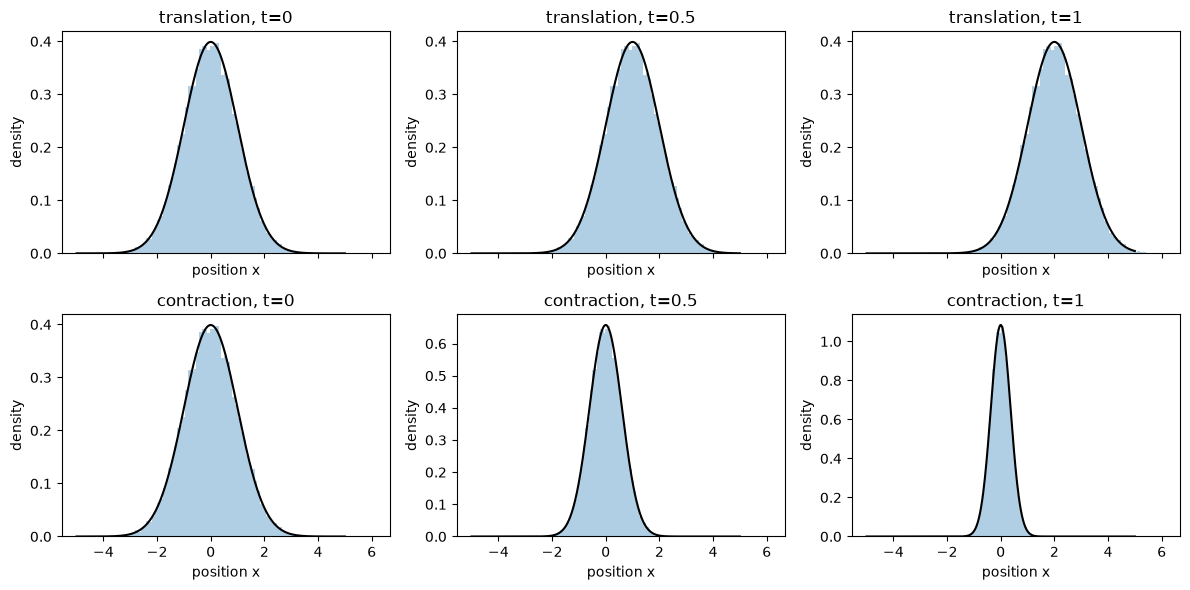

In [2]:
x0 = rng.normal(size=30000)
grid = np.linspace(-5,5,500)
normal_pdf=lambda x: np.exp(-x*x/2)/np.sqrt(2*np.pi)
fig,axes=plt.subplots(2,3,figsize=(12,6),sharex=True)
for row,field in enumerate(["translation","contraction"]):
    for col,t in enumerate([0.,0.5,1.]):
        x=x0+2*t if row==0 else x0*np.exp(-t)
        p=normal_pdf(grid-2*t) if row==0 else np.exp(t)*normal_pdf(grid*np.exp(t))
        axes[row,col].hist(x,bins=80,density=True,alpha=.35)
        axes[row,col].plot(grid,p,'k')
        axes[row,col].set_title(f"{field}, t={t:g}")
        axes[row,col].set_xlabel("position x")
        axes[row,col].set_ylabel("density")
plt.tight_layout(); plt.show()

### Reading the density plots

Translation moves the center from 0 to 2. Contraction keeps the center at 0 and reduces the standard deviation from 1 to $e^{-1}$. In both cases, the area under the density is one. Histogram roughness is finite-sample variation; it is not numerical ODE error, because this cell used exact trajectories.

## 3. A fixed interval can gain or lose probability

Choose $[a,b]=[-0.75,0.75]$. Define its probability at time $t$ as

$$M(t)=P(a\le X_t\le b)=\int_a^b p_t(x)\,dx.$$

The probability flux is $j(x,t)=p_t(x)v(x,t)$. Probability entering through the left endpoint contributes $j(a,t)$, while probability leaving through the right endpoint contributes $-j(b,t)$:

$$\frac{dM(t)}{dt}=j(a,t)-j(b,t).$$

This signed formula also covers leftward motion. For instance, negative flux at the right endpoint means particles enter the interval there.

If this balance holds for every fixed interval, then

$$\int_a^b\partial_t p_t(x)\,dx
=-\int_a^b\partial_x[p_t(x)v(x,t)]\,dx,$$

which gives the **continuity equation**

$$\partial_t p_t(x)=-\partial_x[p_t(x)v(x,t)].$$

Conservation is the probability-balance principle; continuity is its local differential equation.

## 4. Follow the endpoints as well

Now move the endpoints using the same flow. The moving interval is $[a+2t,b+2t]$ under translation and $[e^{-t}a,e^{-t}b]$ under contraction. It contains exactly the particles that started in $[a,b]$:

$$P\bigl(\Psi_{0\to t}(a)\le X_t\le\Psi_{0\to t}(b)\bigr)
=P(a\le X_0\le b).$$

The next cell compares empirical fixed-interval probability, its exact Gaussian-CDF formula, and moving-interval probability. It also checks that a finite-difference derivative of the exact probability agrees with the boundary flux.

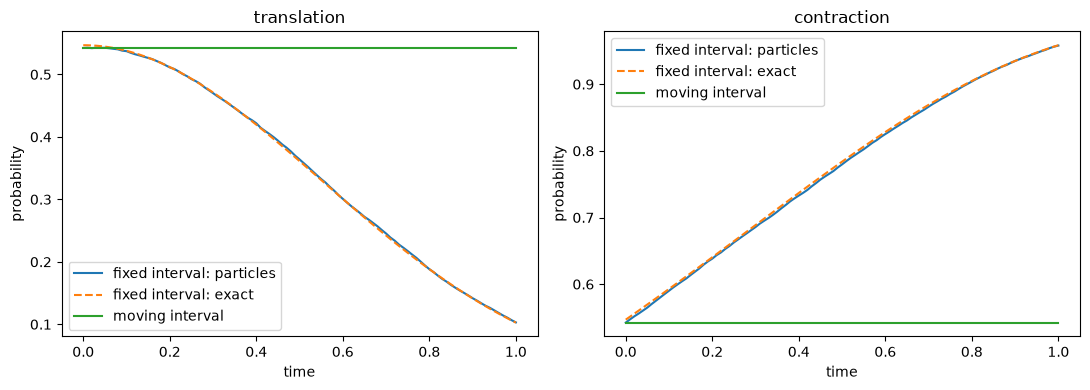

In [3]:
times=np.linspace(0,1,101)
a,b=-.75,.75
fig,axes=plt.subplots(1,2,figsize=(11,4))
for row in range(2):
    fixed=[]; moving=[]; exact=[]; flux=[]
    for t in times:
        x=x0+2*t if row==0 else x0*np.exp(-t)
        left,right=(a+2*t,b+2*t) if row==0 else (a*np.exp(-t),b*np.exp(-t))
        fixed.append(np.mean((x>=a)&(x<=b)))
        moving.append(np.mean((x>=left)&(x<=right)))
        exact.append(ndtr(b-2*t)-ndtr(a-2*t) if row==0 else ndtr(b*np.exp(t))-ndtr(a*np.exp(t)))
        flux.append(2*(normal_pdf(a-2*t)-normal_pdf(b-2*t)) if row==0 else -a*np.exp(t)*normal_pdf(a*np.exp(t))+b*np.exp(t)*normal_pdf(b*np.exp(t)))
    assert np.ptp(moving)==0
    # The central finite difference agrees with the instantaneous boundary flux.
    assert np.max(np.abs(np.gradient(exact,times)[1:-1]-np.array(flux)[1:-1]))<0.001
    axes[row].plot(times,fixed,label="fixed interval: particles")
    axes[row].plot(times,exact,'--',label="fixed interval: exact")
    axes[row].plot(times,moving,label="moving interval")
    axes[row].set(xlabel="time",ylabel="probability",title=["translation","contraction"][row]); axes[row].legend()
plt.tight_layout(); plt.show()


### Reading the interval plots

Under translation, the fixed interval loses probability as the distribution moves right. Under contraction, it gains probability as particles approach zero. The moving interval has constant probability in both cases. Constant total probability does not require constant probability in every fixed spatial region.

## 5. Numerical trajectories introduce a separate error

Explicit Euler takes a positive step $h$ using

$$x_{k+1}=x_k+h\,v(x_k,t_k).$$

For contraction and $h=1/N$, starting from $x_0=1$ gives

$$x_N^{\mathrm{Euler}}=(1-1/N)^N,\qquad x(1)=e^{-1}.$$

The next cell compares these positions. No particles are randomly sampled in this calculation, so the discrepancy measures discretization error directly.

In [4]:
for steps in [10,50,200]:
    euler=(1-1/steps)**steps
    print(f"contraction: {steps=}, |Euler(1)-exp(-1)|={abs(euler-np.exp(-1)):.6f}")
print(f"Runtime: {time.perf_counter()-started:.1f} s")

contraction: steps=10, |Euler(1)-exp(-1)|=0.019201
contraction: steps=50, |Euler(1)-exp(-1)|=0.003710
contraction: steps=200, |Euler(1)-exp(-1)|=0.000922
Runtime: 0.3 s


### What the experiment establishes

The Euler error decreases as the step size shrinks. It is about $0.0192$ for 10 steps and $0.00092$ for 200 steps. These are errors in a numerical trajectory, unlike the histogram fluctuations above.

The examples show how a vector field determines particle trajectories and induced densities. They do not assume that simply contracting particles samples a desired distribution: contraction eventually concentrates this population at zero.

## Exercises

1. Replace the initial normal distribution with an equally weighted mixture of two Gaussians. Does moving-interval conservation change? Why?
2. For translation, compute $M(t)=\Phi(b-2t)-\Phi(a-2t)$ and differentiate it. Recover the flux formula.
3. Explain why contraction raises the central density even though the probability of the moving interval stays constant.
4. Which of the observed errors can be reduced by adding particles, and which requires reducing the solver step size?

The next notebook constructs a field for a prescribed diffusion density path and uses its inverse evolution to generate samples.